In [1]:
import numpy as np

text = [
    "code c++ trên vim mượt hơn",
    "cấp phát động trong c++ dùng heap",
    "ubuntu chạy ngon trên máy dell",
    "quản lý bộ nhớ c++ cần con trỏ",
    "giao diện terminal nhẹ hơn gui",
    "học đại số tuyến tính hcmus hơi khoai",
    "viết bash script tự động hóa",
    "c++ quản lý bộ nhớ thủ công"
]

vocab = sorted({w for s in text for w in s.lower().split()})

def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        if w in vocab:
            v[vocab.index(w)] += 1
    return v

X = np.array([to_vector(s) for s in text])
print(X.shape)

(8, 44)


- Mỗi hàng đại diện cho 1 câu (8 câu -> 8 hàng).
- Mỗi cột đại diện cho 1 từ duy nhất trong vocab (44 từ -> 44 cột).
- Giá trị `X[i,j]` là số lần từ thứ `j` xuất hiện trong câu thứ `i`.

```
# Định dạng của đoạn này là mã
```



In [2]:
print("Shape của X:", X.shape)

mean_vec = X.mean(axis=0)
print("Shape của mean_vec:", mean_vec.shape)

Xc = X - mean_vec
print("Shape của Xc:", Xc.shape)

Shape của X: (8, 44)
Shape của mean_vec: (44,)
Shape của Xc: (8, 44)


In [3]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
    Y_norm = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return X_norm @ Y_norm.T

S = cosine_similarity(X)
print(np.round(S, 2))

[[1.   0.15 0.17 0.14 0.17 0.   0.   0.15]
 [0.15 1.   0.   0.13 0.   0.   0.15 0.14]
 [0.17 0.   1.   0.   0.   0.   0.   0.  ]
 [0.14 0.13 0.   1.   0.   0.   0.   0.67]
 [0.17 0.   0.   0.   1.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   1.   0.   0.  ]
 [0.   0.15 0.   0.   0.   0.   1.   0.  ]
 [0.15 0.14 0.   0.67 0.   0.   0.   1.  ]]


In [4]:
def search(query, top_k=3):
    q_vec = to_vector(query).reshape(1, -1)
    sim_scores = cosine_similarity(q_vec, X).ravel()
    top_idx = np.argsort(sim_scores)[::-1][:top_k]
    return [(int(i), float(sim_scores[i])) for i in top_idx]

query = "quản lý bộ nhớ c++"
print(f"Query: {query!r}")
for i, score in search(query, top_k=3):
    print(f"  Câu {i}: {score:.3f}")

Query: 'quản lý bộ nhớ c++'
  Câu 7: 0.845
  Câu 3: 0.791
  Câu 0: 0.183


 Nhận xét
Dựa vào ma trận tương đồng, ta thấy cặp câu 3 và câu 7 có hệ số tương đồng cao nhất.
Trực quan:
- Câu 3: "quản lý bộ nhớ c++ cần con trỏ"
- Câu 7: "c++ quản lý bộ nhớ thủ công"
-> Hai câu này trùng nhau nguyên cụm: "c++", "quản", "lý", "bộ", "nhớ".

Các cặp câu có hệ số tương đồng bằng 0 là không có từ vựng nào chung. Khác biệt nhất là câu 5 "học đại số tuyến tính hcmus hơi khoai" và câu 6 "viết bash script tự động hóa" vì hai câu này đi lệch hẳn trọng tâm, gần như bằng 0 khi so với toàn bộ các câu còn lại trong nhóm chủ đề C++ và hệ điều hành.

In [5]:
Xc = X - X.mean(axis=0)

U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

coords = U[:, :2] * S[:2]

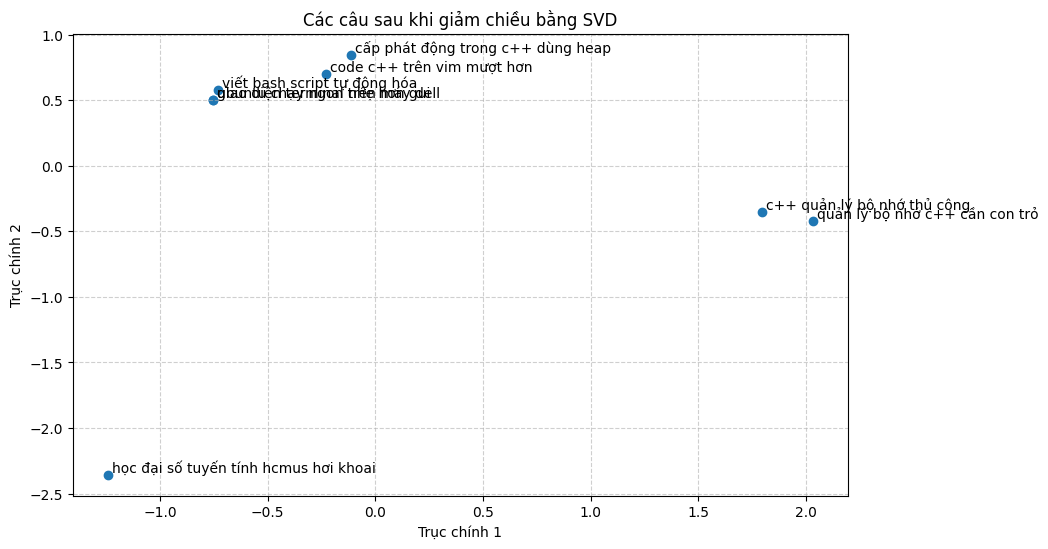

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(coords[:, 0], coords[:, 1])

for i, s in enumerate(text):
    plt.annotate(s, (coords[i, 0] + 0.02, coords[i, 1] + 0.02), fontsize=10)

plt.xlabel("Trục chính 1")
plt.ylabel("Trục chính 2")
plt.title("Các câu sau khi giảm chiều bằng SVD")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Nhận xét
Các câu có cùng chủ đề như nhóm câu 1, 3, 7 (về C++ và bộ nhớ) hoặc nhóm câu 2, 4, 6 (về Linux/Terminal) đều có xu hướng tập trung nằm gần nhau thành từng cụm trên đồ thị.

Về mặt toán học, vì ta đã trừ đi giá trị trung bình (`Xc = X - X.mean(axis=0)`) trước khi phân rã, nên việc áp dụng SVD trên tập dữ liệu đã được center này hoàn toàn tương đương với PCA (Principal Component Analysis). Các hàng của ma trận `Vt` chính là các trục chính (principal axes) — tức eigenvector của ma trận hiệp phương sai — và bình phương của giá trị kỳ dị `S` sẽ tỉ lệ thuận với phương sai dọc theo mỗi trục. Trục chính 1 đại diện cho hướng mà dữ liệu biến thiên mạnh nhất; ở tập dữ liệu này, nó tự động nắm bắt được sự khác biệt lớn nhất về chủ đề (nhóm lập trình C++ vs nhóm công cụ Linux), do đó chỉ cần giữ lại 2 trục mạnh nhất là đã đủ thông tin để tách biệt các cụm rồi.